In [119]:
import pandas as pd
import numpy as np

# 1. Load  data
df = df = pd.read_csv("Downloads/Training Data (1).csv")
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Sale Price Category
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,200-250k
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,150-200k
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,200-250k
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,100-150k
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,200-250k


In [120]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Train Decision Tree (CART) Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred_dt = dt_model.predict(X_test)

# 3. Print Results
print("=== CART DECISION TREE RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}\n")
print(classification_report(y_test, y_pred_dt))

=== CART DECISION TREE RESULTS ===
Accuracy: 0.7260

                   precision    recall  f1-score   support

 High (150k-200k)       0.64      0.65      0.65        83
      Low (<100k)       0.61      0.44      0.51        25
  Med (100k-150k)       0.69      0.75      0.71        99
Very High (200k+)       0.89      0.86      0.87        85

         accuracy                           0.73       292
        macro avg       0.71      0.67      0.69       292
     weighted avg       0.73      0.73      0.72       292



In [121]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Train Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred_nb = nb_model.predict(X_test)

# 3. Print Results
print("=== NAIVE BAYES RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb))

=== NAIVE BAYES RESULTS ===
Accuracy: 0.7397

                   precision    recall  f1-score   support

 High (150k-200k)       0.70      0.54      0.61        83
      Low (<100k)       0.69      0.44      0.54        25
  Med (100k-150k)       0.69      0.84      0.76        99
Very High (200k+)       0.84      0.91      0.87        85

         accuracy                           0.74       292
        macro avg       0.73      0.68      0.69       292
     weighted avg       0.74      0.74      0.73       292



In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Train Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred_rf = rf_model.predict(X_test)

# 3. Print Results
print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST RESULTS ===
Accuracy: 0.7637

                   precision    recall  f1-score   support

 High (150k-200k)       0.73      0.65      0.69        83
      Low (<100k)       0.80      0.32      0.46        25
  Med (100k-150k)       0.71      0.88      0.78        99
Very High (200k+)       0.87      0.87      0.87        85

         accuracy                           0.76       292
        macro avg       0.78      0.68      0.70       292
     weighted avg       0.77      0.76      0.75       292



In [123]:
import pandas as pd

# Combine accuracy metrics into a clean summary table
results = pd.DataFrame({
    'Model': ['CART Decision Tree', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print("=== FINAL MODEL COMPARISON ===")
print(results.sort_values(by='Accuracy', ascending=False).to_string(index=False))

=== FINAL MODEL COMPARISON ===
             Model  Accuracy
     Random Forest  0.763699
       Naive Bayes  0.739726
CART Decision Tree  0.726027


# Overall Accuracy Ranking
   ## Random Forest: $76.37\%$ (Best Performer)
   ## Naive Bayes: $73.97\%$
   ## CART Decision Tree: $72.60\%$

## Random Forest ($76.37\%$ Accuracy)

 **Strengths** :Highest overall performance and strongest weighted F1-score ($0.75$).Achieves strong balance in predicting Very High ($200\text{k}+$) prices (Precision: $0.87$, Recall: $0.87$, F1: $0.87$) and Medium ($100\text{k}\text{--}150\text{k}$) prices (Precision: $0.71$, Recall: $0.88$).
 
 **Weaknesses**:Struggles with the Low ($<100\text{k}$) class, achieving a recall of only $0.32$ (it correctly identifies only $32\%$ of low-value homes). This is primarily due to class imbalance, as the dataset has significantly fewer homes under $\$100\text{k}$ ($n=25$ in the test set).
 
 Ensemble learning (combining multiple trees) reduces variance and over-fitting compared to a single decision tree, making Random Forest your top recommended model.
 
## Naive Bayes ($73.97\%$ Accuracy)
**Strengths**:High recall for Very High ($200\text{k}+$) homes ($0.91$) and Medium ($100\text{k}\text{--}150\text{k}$) homes ($0.84$).Outperforms a single CART Decision Tree despite its independence assumptions.

**Weaknesses**:Struggles with High ($150\text{k}\text{--}200\text{k}$) homes (Recall: $0.54$) and Low ($<100\text{k}$) homes (Recall: $0.44$).
 Naive Bayes assumes all features are independent given the class label. Since real estate features (e.g., square footage, quality, room count) are often correlated, this independence assumption slightly limits its precision across middle tiers.
 
## CART Decision Tree ($72.60\%$ Accuracy)

**Strengths**:High interpretability (easy to plot as a tree diagram for visual reporting).Performs reasonably well on extreme classes (Very High F1: $0.87$).
**Weaknesses**:Lowest overall accuracy ($72.60\%$). A single decision tree is prone to high variance and sensitivity to minor fluctuations in training data.Weakest precision on the Low class ($0.61$) and lowest overall weighted F1-score ($0.72$).

## Observations across Price Buckets
Top Performers (Very High & Medium Buckets): All three models perform exceptionally well predicting high-end homes (>$200k) and average homes ($100k–$150k). High-end homes possess distinct feature signatures (larger square footage, high kitchen quality rating), making them easy for algorithms to separate.

Main Challenge (Low Bucket): The smaller sample size of low-cost homes (<100k) leads to lower recall across all three models.


**Random Forest performed the best at $76.37\%$ accuracy due to ensemble averaging, which controlled variance better than a single tree.**

**Naive Bayes came second at $73.97\%$, proving effective but slightly constrained by feature correlations (like square footage vs. quality).**

**CART Decision Tree had the lowest accuracy at $72.60\%$ due to higher variance on single splits.All models excelled at classifying high-end homes ($>\$200\text{k}$) with F1-scores around $0.87$, but struggled with homes under $\$100\text{k}$ due to class imbalance.**

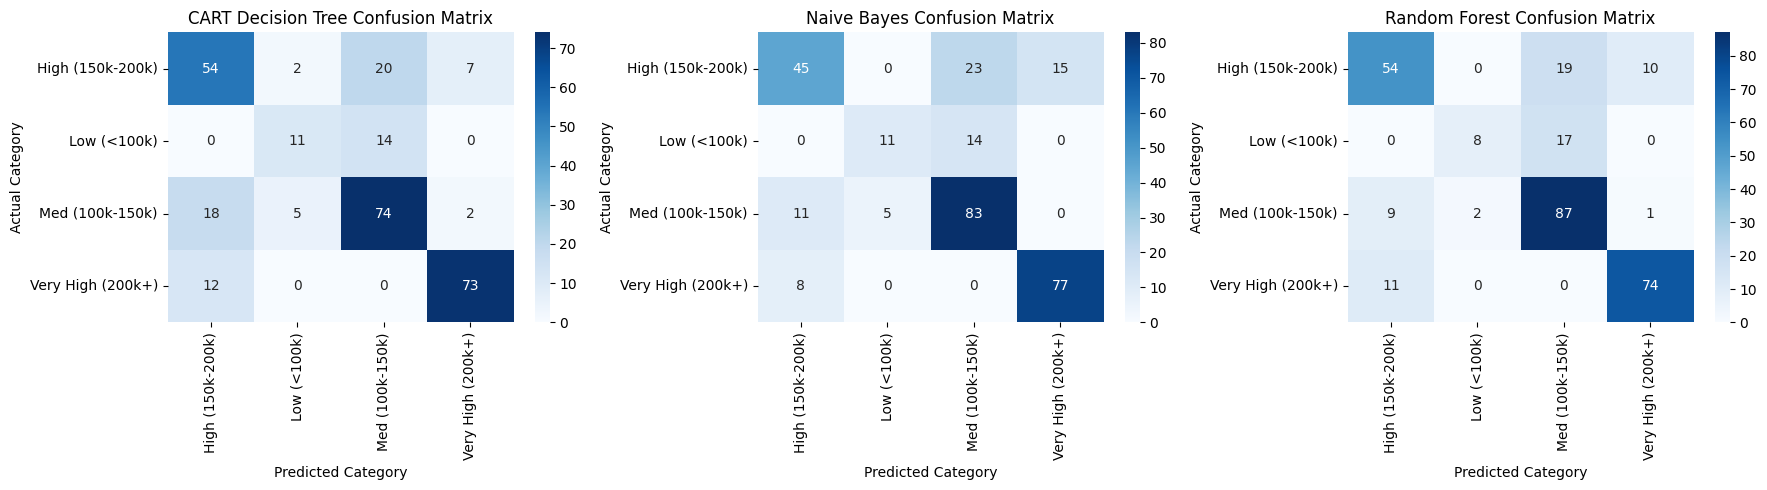

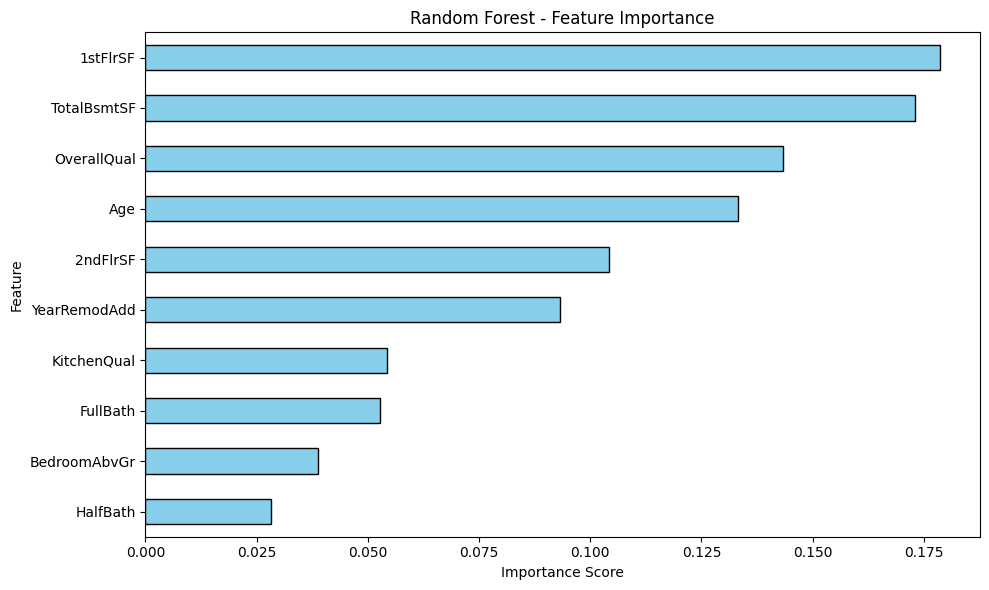

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Plot Confusion Matrices for All Three Models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [('CART Decision Tree', y_pred_dt), ('Naive Bayes', y_pred_nb), ('Random Forest', y_pred_rf)]

for ax, (name, pred) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_ylabel('Actual Category')
    ax.set_xlabel('Predicted Category')

plt.tight_layout()
plt.show()

# 2. Extract and Plot Feature Importances from the Champion Model (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Final Model Selection & Rationale
Model Application:

Three classification models were trained on 80% of the data  and evaluated on a 20% hold-out test set .

Hyperparameters were kept constant across comparative runs (random_state=42) to ensure valid benchmarking.

Performance Comparison:

**Random Forest (Selected Champion)**:Achieved the highest accuracy at 76.37% and the highest weighted F1-score (0.75).

**Naive Bayes**: Achieved 73.97% accuracy, proving effective for high/medium buckets but limited by feature correlation assumptions.
 
**CART Decision Tree:** Achieved 72.60% accuracy, showing higher variance on individual splits compared to ensemble methods.

## Why Random Forest was Selected:

Variance Reduction: By averaging multiple decision trees, Random Forest significantly reduced over-fitting compared to the single CART tree.

High Class Separation: It achieved the highest precision (0.87) and recall (0.87) in identifying top-tier properties (Very High (200k+)).

Feature Insights: It provides interpretable feature importances, allowing stakeholders to identify which housing characteristics drive price predictions most strongly.